### Analytical Evaluation of the Effective Dynamics (FAPT)

While the numerical propagation of the effective state is efficient for single pulse sequences, large parameter sweeps and pulse optimizations require a less computationally demanding approach. To achieve this, the perturbative construction can be evaluated analytically.

Instead of performing the time-evolution numerically over many small steps $\delta t$, this approach uses closed-form symbolic expressions for both the transformation matrix $W(\boldsymbol\lambda)$ and the effective Hamiltonian $H_{\mathrm{eff,ad}}$. The time evolution operator $U(t, t_i)$ over the entire pulse duration is then approximated using the **Magnus expansion** (up to second order), effectively evaluating the evolution in a single analytical step. 

The following code tests this analytical framework by substituting symbolic pulse shapes (like a Gaussian amplitude) into the analytically derived Magnus operator.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sympy as sp
from utils import * 
from FAPT import * 
from pulse_optimization import * 
s = Simulation()
import matplotlib.pyplot as plt

rH = 2
rW = 1
use_gauss = True
pulse_name = "gauss" if use_gauss else "tanh"


def setup_paper_style():
    """Sets Matplotlib defaults for scientific publication layouts."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern", "Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "text.usetex": False,
        "axes.labelsize": 11.5,
        "font.size": 11,
        "legend.fontsize": 9.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 12,
        "axes.titlesize": 11.5,
        "lines.linewidth": 1.4,
        "lines.markersize": 5.0,
    })


def load_and_plot_standard_custom(
    show=True, use_FAPT=False, pulse="gauss", include_custom=True
):
    # Daten laden
    name_addition = "" if not use_FAPT else "_FAPT"
    custom_str = "" if include_custom else "_no_custom"
    save_path = f"Figure/drag_results/standard_custom_comparison{name_addition}_{pulse}{custom_str}.pdf"

    cos_data = np.load("operational_res/cos_popfids_data.npz")
    standard_data = np.load(
        f"operational_res/drag_popfids/drag_popfids_data_standard{name_addition}_{pulse}.npz"
    )

    tg_cos, infid_cos = cos_data["tg_list"], cos_data["infid_pop_list"]
    (
        tg_standard,
        direct_standard,
        floq_standard,
    ) = (
        standard_data["tg_list"],
        standard_data["direct"],
        standard_data["floq"],
    )

    if include_custom:
        custom_data = np.load(
            f"operational_res/drag_popfids/drag_popfids_data_custom{name_addition}_{pulse}.npz"
        )
        (
            tg_custom,
            direct_custom,
            floq_custom,
        ) = (
            custom_data["tg_list"],
            custom_data["direct"],
            custom_data["floq"],
        )

    setup_paper_style()

    # Pulstyp ermitteln und Labels/Farben anpassen
    is_tanh = "tanh" in str(pulse).lower()
    pulse_label = "tanh" if is_tanh else "Gaussian"

    if is_tanh:
        c_cos = "#1f77b4"       # Blau als Referenz
        c_standard = "#ff7f0e"  # Orange für Standard DRAG
        c_custom = "#7b2cbf"    # Violett/Purpur für Custom DRAG
    else:
        c_cos = "#1f77b4"       # Blau als Referenz
        c_standard = "#d62728"  # Rot für Standard DRAG
        c_custom = "#2ca02c"    # Grün für Custom DRAG

    plot_style = {
        "axes.labelsize": 12.0,
        "axes.titlesize": 12.5,
        "xtick.labelsize": 10.5,
        "ytick.labelsize": 10.5,
        "legend.fontsize": 9.0,
        "lines.linewidth": 2.0,
        "lines.markersize": 6.0,
    }

    with plt.rc_context(plot_style):
        fig, ax = plt.subplots(figsize=(6.8, 3.8), dpi=300)

        # Cosine reference
        ax.semilogy(
            tg_cos,
            infid_cos,
            "-",
            color=c_cos,
            marker=".",
            markerfacecolor="white",
            markeredgecolor=c_cos,
            markeredgewidth=1.8,
            label=r"Cosine (Direct)",
        )

        # Standard DRAG
        ax.semilogy(
            tg_standard,
            direct_standard,
            "-",
            color=c_standard,
            marker="o",
            mfc="white",
            mec=c_standard,
            mew=1.5,
            label=rf"Standard DRAG ({pulse_label}, Direct)",
        )
        ax.semilogy(
            tg_standard,
            floq_standard,
            "--",
            color=c_standard,
            marker="o",
            mfc="white",
            mec=c_standard,
            mew=1.0,
            lw=1.4,
            ms=4.5,
            alpha=0.40,
            label=rf"Standard DRAG ({pulse_label}, Floquet)",
        )

        # Custom DRAG (nur plottet, wenn include_custom=True)
        if include_custom:
            ax.semilogy(
                tg_custom,
                direct_custom,
                "-",
                color=c_custom,
                marker="s",
                mfc="white",
                mec=c_custom,
                mew=1.5,
                label=rf"Custom DRAG ({pulse_label}, Direct)",
            )
            ax.semilogy(
                tg_custom,
                floq_custom,
                "--",
                color=c_custom,
                marker="s",
                mfc="white",
                mec=c_custom,
                mew=1.0,
                lw=1.4,
                ms=4.5,
                alpha=0.40,
                label=rf"Custom DRAG ({pulse_label}, Floquet)",
            )

        fapt_str = " (FAPT)" if use_FAPT else ""
        ax.set_xlabel(r"Gate duration $t_g$ [ns]")
        ax.set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
        ax.set_title(
            rf"{pulse_label} Pulse{fapt_str}: Population Infidelity Comparison",
            fontweight="bold",
        )
        ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
        ax.legend(
            loc="best",
            ncol=2,
            frameon=True,
            fancybox=False,
            edgecolor="gray",
            framealpha=0.9,
        )

        fig.tight_layout()

        if save_path:
            output_file = Path(save_path)
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, bbox_inches="tight")

        if show:
            plt.show()

    return fig, ax

In [2]:
from pathlib import Path
import numpy as np
import sympy as sp

DRIVE_DIRECTORY = Path("operational_res/analytical_drive_data")

def load_analytical_drive(pulse_type, drive_directory=DRIVE_DIRECTORY):
    file_path = Path(drive_directory) / f"analytical_drive_{pulse_type}_standard.npz"
    if not file_path.exists():
        raise FileNotFoundError(f"Die Datei '{file_path}' wurde nicht gefunden.")

    with np.load(file_path, allow_pickle=False) as saved_data:
        wd0_raw = saved_data["wd0_srepr"].item()
        return {
            "Ar": sp.sympify(saved_data["Ar_srepr"].item()),
            "Ai": sp.sympify(saved_data["Ai_srepr"].item()),
            "dwd": sp.sympify(saved_data["dwd_srepr"].item()),
            "wd0": sp.sympify(wd0_raw) if wd0_raw else None,
        }

def get_symbol_by_name(expressions, symbol_name):
    free_symbols = set().union(*(expr.free_symbols for expr in expressions if expr is not None))
    matching_symbols = [s for s in free_symbols if s.name == symbol_name]
    if not matching_symbols:
        raise KeyError(f"Das Symbol '{symbol_name}' wurde nicht in den Ausdrücken gefunden.")
    return matching_symbols[0]

# --- Laden & Substitution basierend auf use_gauss ---
pulse_type = pulse_name
drive = load_analytical_drive(pulse_type=pulse_type)

wd0_expr = drive["wd0"]
wd0_val = float(wd0_expr) if wd0_expr is not None else 0.0

# Ausdrücke direkt durch Subskription aufbereiten
Ar_expr, Ai_expr, dwd_expr = (
    expr.subs(wd0_expr, wd0_val) if wd0_expr is not None else expr
    for expr in (drive["Ar"], drive["Ai"], drive["dwd"])
)

# Symbole aus den aktuell geladenen Ausdrücken extrahieren
t_sym = get_symbol_by_name((Ar_expr, Ai_expr, dwd_expr), "t")
tg_sym = get_symbol_by_name((Ar_expr, Ai_expr, dwd_expr), "t_g")
sigma_sym = get_symbol_by_name((Ar_expr, Ai_expr, dwd_expr), r"\sigma")

display(dwd_expr)

-8.43769498715119e-15 + 20.33898305084746*pi**2*(exp(1/(8*\sigma**2)) - exp((2*t - t_g)**2/(8*\sigma**2*t_g**2)))**2*exp(-(2*t - t_g)**2/(4*\sigma**2*t_g**2))/(t_g**2*(sqrt(2)*sqrt(pi)*\sigma*exp(1/(8*\sigma**2))*erf(sqrt(2)/(4*\sigma)) - 1)**2)

In [3]:
def replace_loaded_symbols(expression, t_sym, sigma_sym, tg_sym):
    symbol_map = {}

    for symbol in expression.free_symbols:
        if symbol.name == "t":
            symbol_map[symbol] = t_sym
        elif symbol.name in ("sigma", "sigma_r", r"\sigma"):
            symbol_map[symbol] = sigma_sym
        elif symbol.name in ("tg", "t_g", r"t_{g}"):
            symbol_map[symbol] = tg_sym

    return expression.xreplace(symbol_map)


def make_analytical_pulse_builder(Ar_expr, Ai_expr, dwd_expr, wd0_expr=None):
    # wd0 dynamisch bestimmen (falls nicht gesetzt/vorhanden, 0.0)
    current_wd0_val = float(wd0_expr) if wd0_expr is not None else 0.0

    def pulse_shape_builder(t_sym, p_syms):
        tg_sym, sigma_sym, wd_offset_sym, amp_scale_sym = p_syms

        Ar = replace_loaded_symbols(expression=Ar_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        Ai = replace_loaded_symbols(expression=Ai_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)
        dwd = replace_loaded_symbols(expression=dwd_expr, t_sym=t_sym, sigma_sym=sigma_sym, tg_sym=tg_sym)

        A = amp_scale_sym * (Ar + sp.I * Ai)
        wd = current_wd0_val + dwd + wd_offset_sym

        return A, wd

    return pulse_shape_builder

In [4]:
# ==============================================================================
# EINMALIGE SYMBOLISCHE FLOQUET-VORBEREITUNG (Dynamisch für gauss / tanh)
# ==============================================================================

# Verwendet die oben dynamisch durch 'pulse_name' / 'pulse_type' geladenen Daten:
analytical_pulse_builder = make_analytical_pulse_builder(
    Ar_expr=drive["Ar"], 
    Ai_expr=drive["Ai"], 
    dwd_expr=drive["dwd"],
    wd0_expr=drive["wd0"]
)

base_parameter_names = [
    "t_g",
    "sigma",
    "wd_offset",
    "amp_scale",
]
param_names = ["wd_offset", "amp_scale"]

def create_binder(include_geometric=False, include_micromotion=False, include_g_correction=False, verbose=False, param_names=param_names):
    H_base, M_base, M_inv_0_base = prepare_floquet_functions(
        pulse_shape_builder=analytical_pulse_builder, 
        p_names=base_parameter_names, 
        s=s, 
        rH=rH, 
        rW=rW, 
        include_geometric=include_geometric, 
        include_micromotion=include_micromotion, 
        include_g_correction=include_g_correction, 
        verbose=verbose
    )
    
    def bind_func(tg_target, sigma, H_base=H_base, M_base=M_base, M_inv_0_base=M_inv_0_base):
        def absolute_parameters(offsets):
            # Falls offsets als einzelnes Container-Objekt (Tupel/Liste/Array) übergeben wurde, entpacken
            if len(offsets) == 1 and isinstance(offsets[0], (tuple, list, np.ndarray)):
                offsets = offsets[0]
                
            values = dict(zip(param_names, offsets))
            return values["wd_offset"], values["amp_scale"]

        def H_func(t, *offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return H_base(t, tg_target, sigma, wd_offset, amp_scale)

        def M_func(t, *offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return M_base(t, tg_target, sigma, wd_offset, amp_scale)

        def M_inv_0_func(*offsets):
            wd_offset, amp_scale = absolute_parameters(offsets)
            return M_inv_0_base(tg_target, sigma, wd_offset, amp_scale)

        H_func.is_time_dependent = getattr(H_base, "is_time_dependent", True)
        return H_func, M_func, M_inv_0_func

    return bind_func

bind_floquet_functions = create_binder()

In [5]:
tg_list = np.linspace(50.0, 700.0, 30)
sigma_r = 0.3 if use_gauss else 0.1
param_ranges = {"wd_offset": (-0.005, 0.05), "amp_scale": (0.8, 1.4)}
s = Simulation()

def for_tg(tg, binder, debug=False, verbose=False, low=False, plot_dynamics=False):
    def sim_pulse(tg, amp, off):
        Ar = sy.lambdify(t_sym, replace_loaded_symbols(Ar_expr, t_sym, sigma_r, tg) * amp, "numpy")
        Ai = sy.lambdify(t_sym, replace_loaded_symbols(Ai_expr, t_sym, sigma_r, tg), "numpy")
        wd = sy.lambdify(t_sym, wd0_val + replace_loaded_symbols(dwd_expr, t_sym, sigma_r, tg) + off, "numpy")

        q = lambda t, args=None: Ar(t) * np.cos(wd(t) * t) + Ai(t) * np.sin(wd(t) * t)
        tlist = np.linspace(0.0, tg, max(101, int(tg * 8)))

        columns = []
        result_a = None

        for initial_state in s.comp_indices:
            result = sesolve([s.H0, [s.V1, q]], s.E_states[initial_state], tlist)

            if initial_state == s.state_a:
                result_a = result

            columns.append([
                state.overlap(result.states[-1])
                for state in s.E_states[s.comp_indices]
            ])

        U = np.column_stack(columns)
        return infid_population(U), q, tlist, result_a

    H_f, M_f, M_i0_f = binder(tg, sigma_r)
    popsize, maxiter, tol = (8, 40, 1e-5) if low else (17, 80, 1e-8)

    p_opt, f_inf = optimize_pulse_parameters(
        H_f, M_f, M_i0_f, param_ranges, s, tg,
        popsize=popsize, maxiter=maxiter, tol=tol, verbose=verbose
    )

    infid_direct, _, tlist, result_a = sim_pulse(
        tg, p_opt["amp_scale"], p_opt["wd_offset"]
    )

    if plot_dynamics:
        states = [s.state_a, s.state_b]
        pops_direct = np.array([
            [abs(s.E_states[state].overlap(psi))**2 for psi in result_a.states]
            for state in states
        ])

        # Floquet-Dynamik aus |a>
        p_vals = (p_opt["wd_offset"], p_opt["amp_scale"])
        t_mids = 0.5 * (tlist[:-1] + tlist[1:])
        dt = tlist[1] - tlist[0]

        if hasattr(H_f, "evaluate_stack"):
            H_all = H_f.evaluate_stack(t_mids, *p_vals)
        elif getattr(H_f, "is_time_dependent", True):
            H_all = np.stack([
                np.asarray(H_f(t, *p_vals), dtype=complex).reshape(s.d_res, s.d_res)
                for t in t_mids
            ], axis=2)
        else:
            H_static = np.asarray(
                H_f(t_mids[0], *p_vals), dtype=complex
            ).reshape(s.d_res, s.d_res)

            H_all = np.repeat(
                H_static[:, :, np.newaxis], len(t_mids), axis=2
            )

        M_inv_0 = np.asarray(
            M_i0_f(*p_vals), dtype=complex
        ).reshape(s.d_res, s.D)

        phi_a = M_inv_0[:, s.state_a]
        U_eff = np.eye(s.d_res, dtype=complex)
        pops_floquet = np.zeros((2, len(tlist)))

        for k, time in enumerate(tlist):
            M = np.asarray(
                M_f(time, *p_vals), dtype=complex
            ).reshape(s.D, s.d_res)

            psi_floquet = M @ U_eff @ phi_a
            norm = np.linalg.norm(psi_floquet)

            if norm < 1e-14:
                raise ValueError(
                    f"Floquet state has vanishing norm at t={time}."
                )

            psi_floquet /= norm
            pops_floquet[:, k] = np.abs(
                psi_floquet[[s.state_a, s.state_b]]
            )**2

            if k < len(t_mids):
                U_eff = scipy_linalg.expm(
                    -1j * H_all[:, :, k] * dt
                ) @ U_eff

        # Plot
        x = tlist / tg
        fig, ax = plt.subplots(figsize=(6.2, 3.2), constrained_layout=True)

        ax.plot(
            x, pops_direct[0],
            color="#1f77b4", lw=1.6,
            label=r"Direct $|\langle a|\psi(t)\rangle|^2$"
        )
        ax.plot(
            x, pops_floquet[0],
            color="black", ls="--", lw=1.8, zorder=5,
            label=r"FPT $|\langle a|\psi(t)\rangle|^2$"
        )
        ax.plot(
            x, pops_direct[1],
            color="#ff7f0e", lw=1.6,
            label=r"Direct $|\langle b|\psi(t)\rangle|^2$"
        )
        ax.plot(
            x, pops_floquet[1],
            color="black", ls="-.", lw=1.8, zorder=5,
            label=r"FPT $|\langle b|\psi(t)\rangle|^2$"
        )

        ax.set_title(r"Initial state $\vert\psi(0)\rangle=\vert a\rangle$")
        ax.set_xlabel(r"$t/t_{\mathrm{g}}$")
        ax.set_ylabel(r"$|\langle i|\psi(t)\rangle|^2$")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(ls=":", lw=0.7, alpha=0.4)
        ax.tick_params(direction="in")
        ax.legend(frameon=False, ncol=2)

        plt.show()

    if debug:
        print(
            "infid_direct:", infid_direct,
            "f_inf:", f_inf,
            "p_opt:", p_opt
        )
    return infid_direct, f_inf, p_opt


def run_tg_sweep(save_name, binder, debug=False, verbose=False, low=False):
    linfid_pop_direct, linfid_pop_floq, linfid_unopt_direct, linfid_unopt_floq = [], [], [], []
    for tg in tqdm(tg_list):
        infid_direct, f_inf, parameters_opt = for_tg(tg, binder, debug=debug, verbose=verbose, low=low)
        linfid_pop_direct.append(infid_direct)
        linfid_pop_floq.append(f_inf)        
    Path("operational_res/drag_popfids").mkdir(parents=True, exist_ok=True)
    np.savez(f"operational_res/drag_popfids/drag_popfids_data_{save_name}_{pulse_name}.npz", tg_list=tg_list, direct=linfid_pop_direct, floq=linfid_pop_floq, unopt_direct=linfid_unopt_direct, unopt_floq=linfid_unopt_floq)

Determine optimal parameters for $t_g=200$~ns

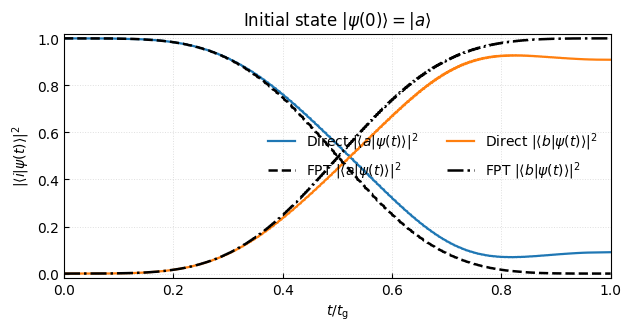

floquet:  3.059419906303873e-08  direct:  0.04542252095513388  p_opt:  {'wd_offset': np.float64(0.00032291182708530215), 'amp_scale': np.float64(1.054880729975074)}


In [6]:
inf_direct, inf_floquet, p_opt = for_tg(200, bind_floquet_functions, low=True, plot_dynamics=True)
print("floquet: ", inf_floquet, " direct: ", inf_direct, " p_opt: ", p_opt)

In [7]:
run_tg_sweep(f"standard", bind_floquet_functions)

  0%|          | 0/30 [00:09<?, ?it/s]


ValueError: Function to integrate must not return a tuple.

In [ ]:
binder = create_binder(include_micromotion=True)
run_tg_sweep("standard_FAPT", binder = binder, debug=False, verbose=False, low=False)

100%|██████████| 30/30 [29:57<00:00, 59.92s/it]


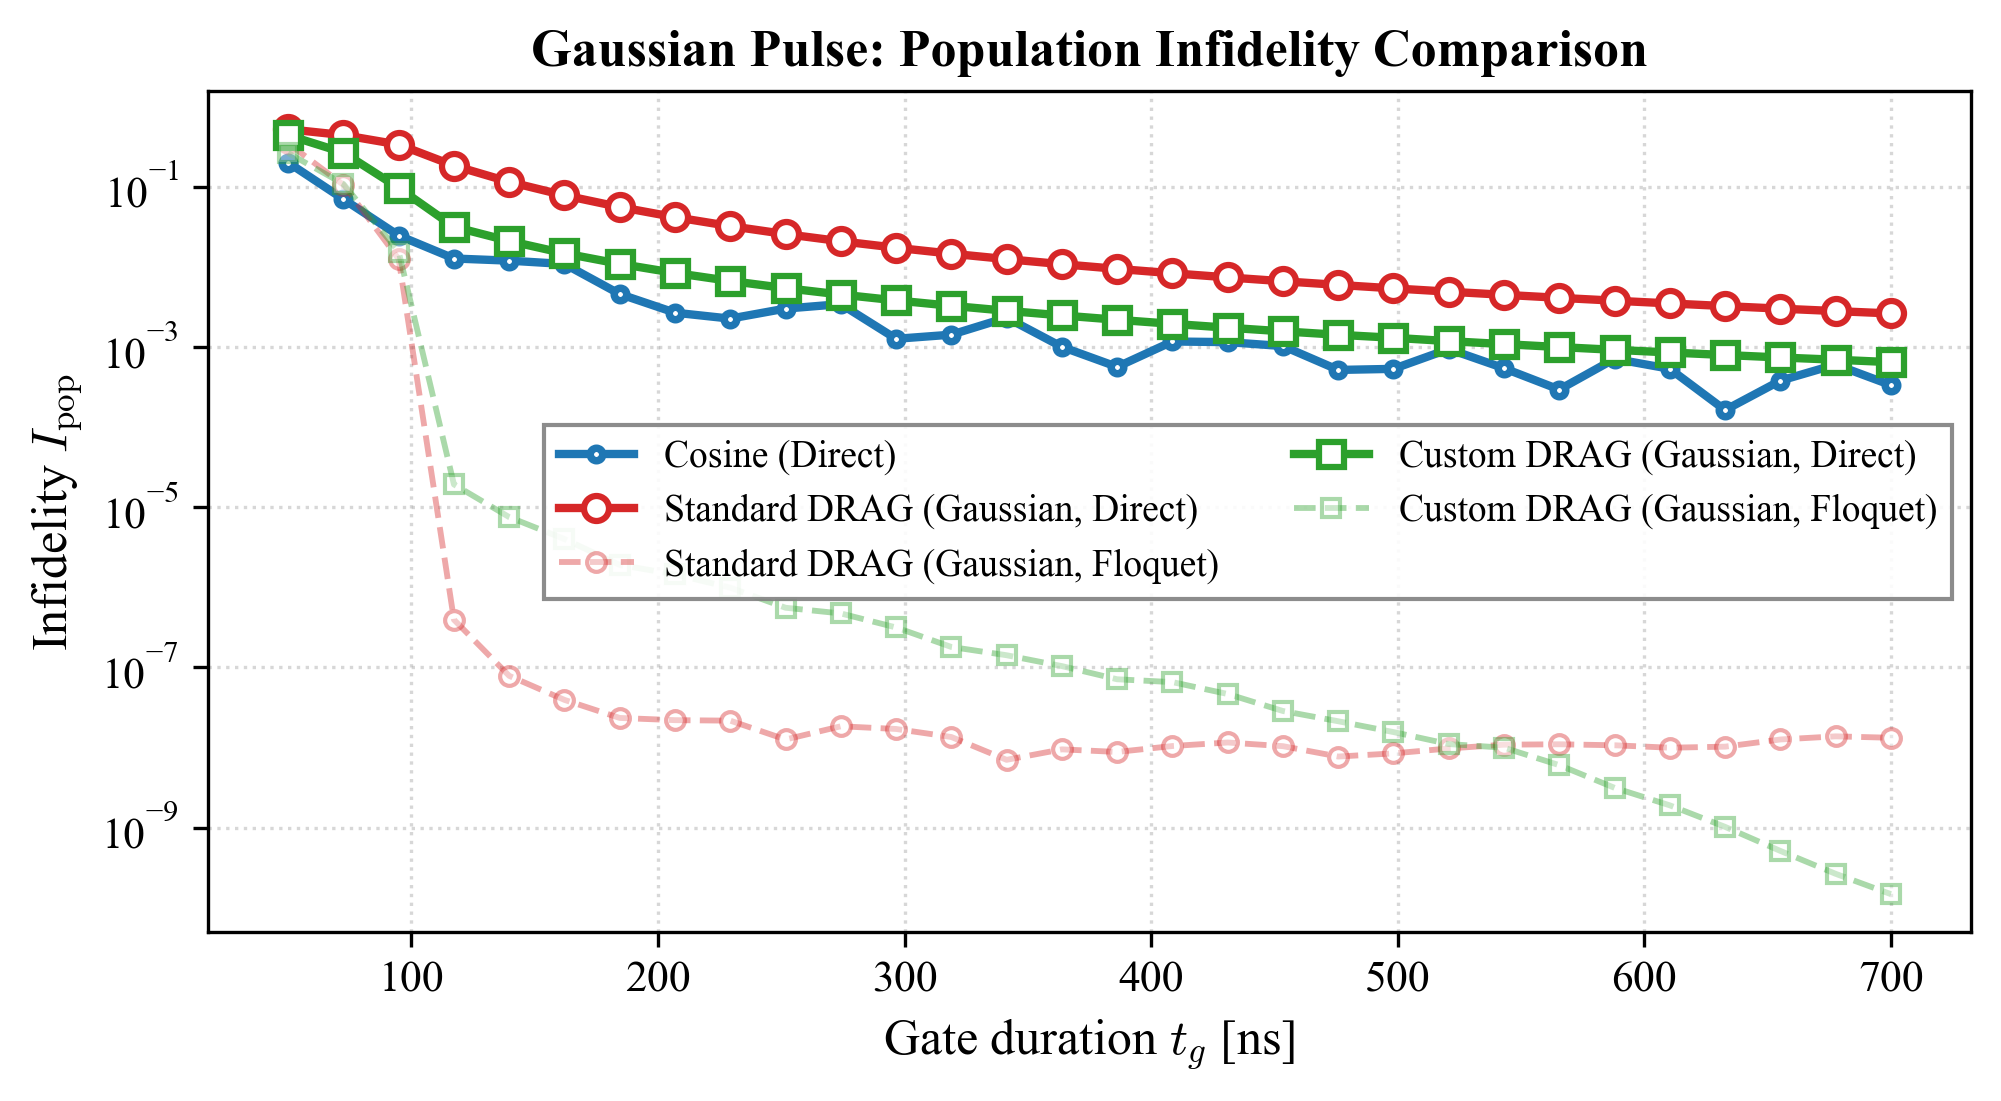

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Pulse: Population Infidelity Comparison'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Infidelity $I_{\\mathrm{pop}}$'>)

In [ ]:
load_and_plot_standard_custom(use_FAPT=False, pulse="gauss")

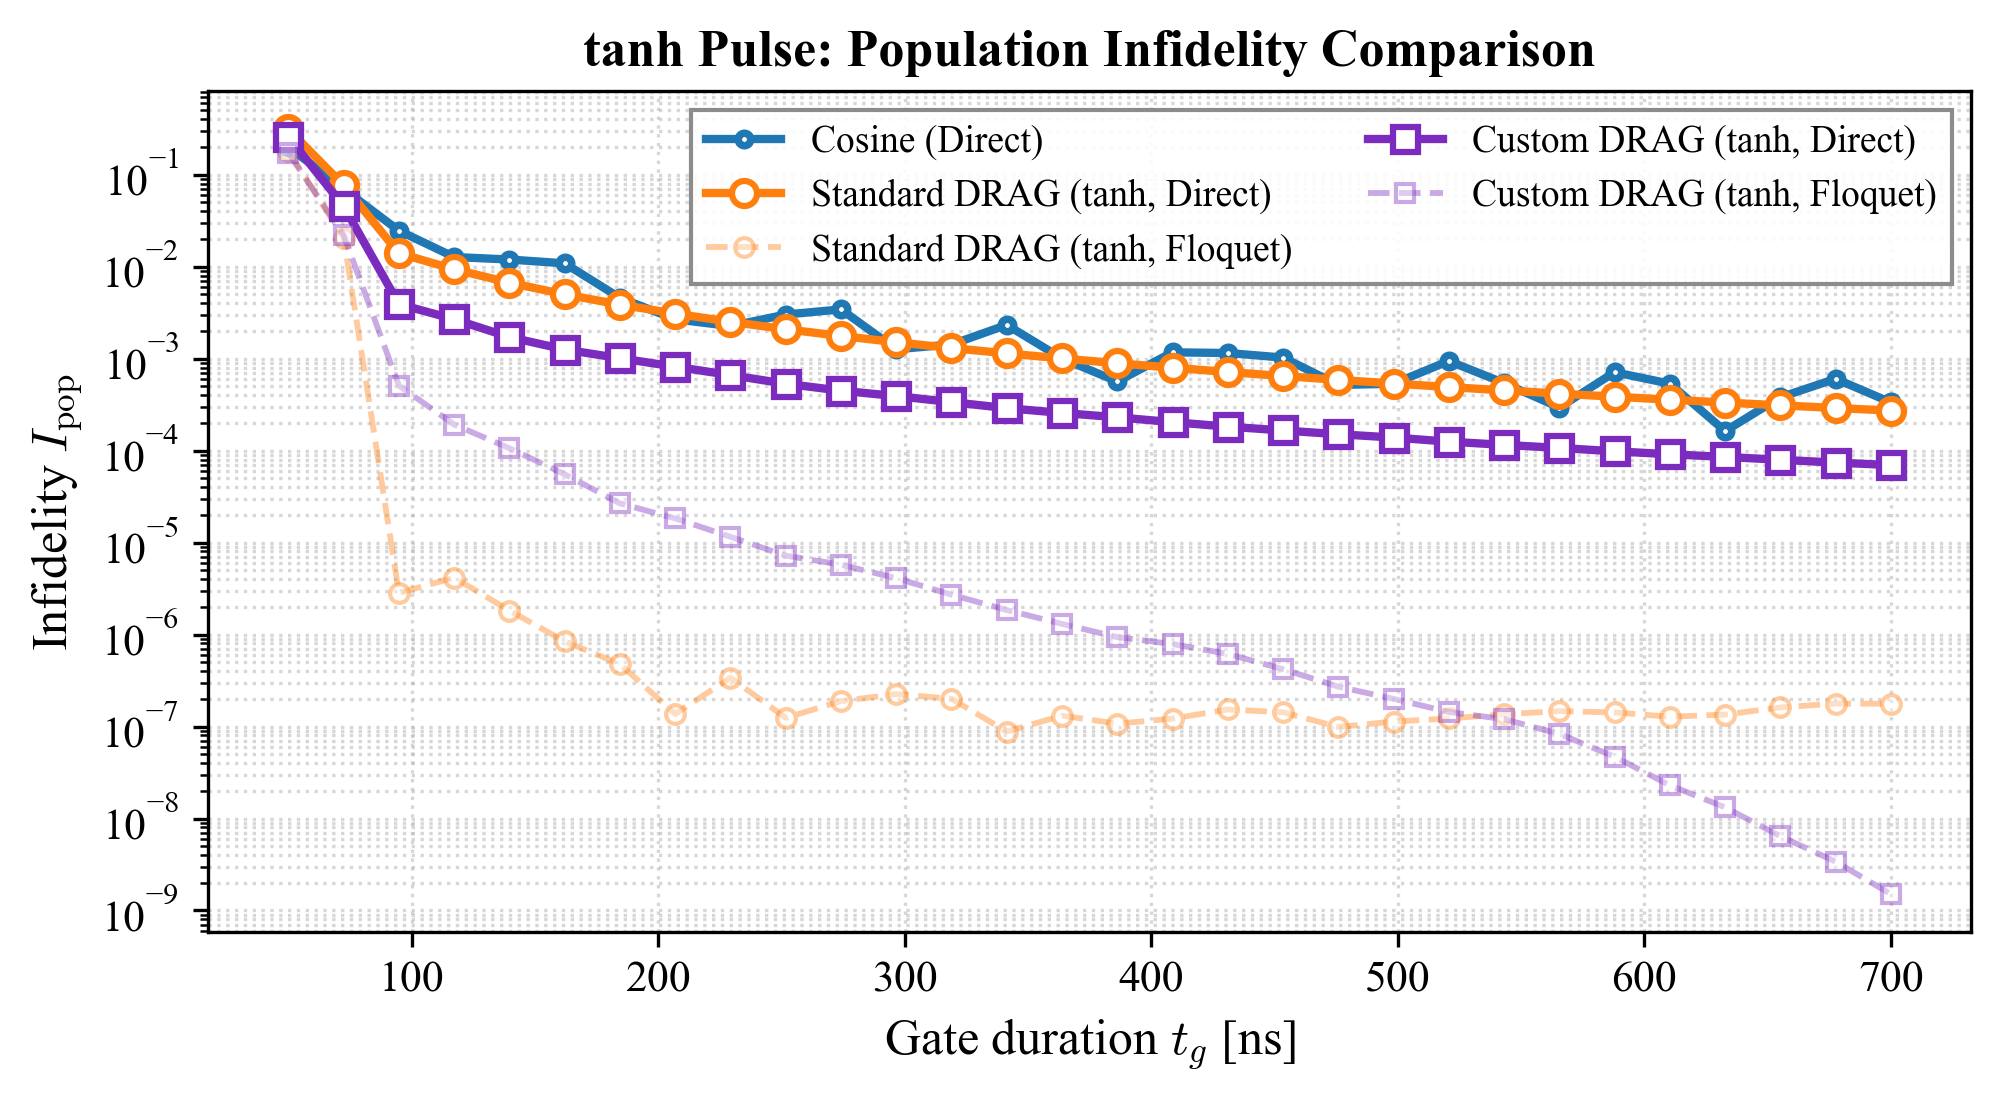

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'tanh Pulse: Population Infidelity Comparison'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Infidelity $I_{\\mathrm{pop}}$'>)

In [ ]:
load_and_plot_standard_custom(use_FAPT=False, pulse="tanh")

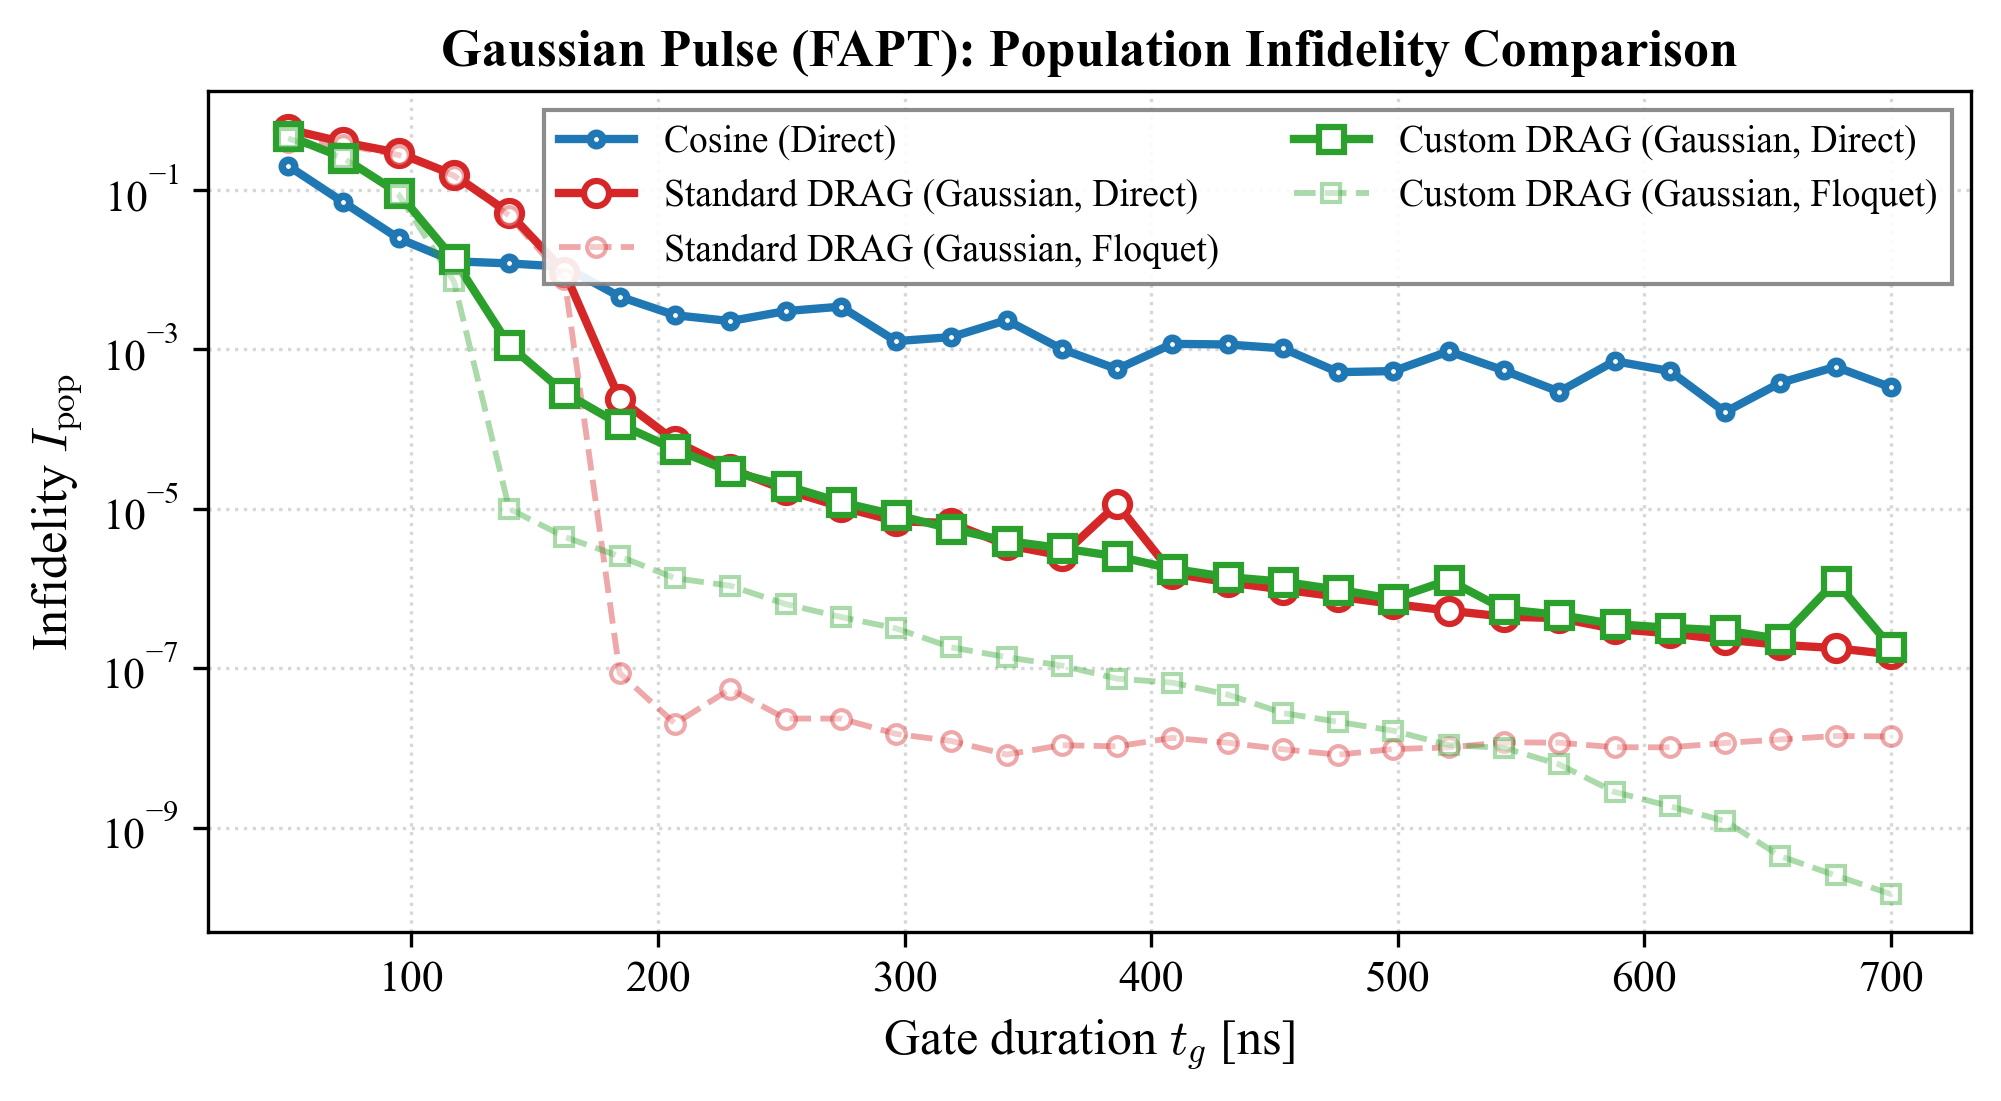

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'Gaussian Pulse (FAPT): Population Infidelity Comparison'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Infidelity $I_{\\mathrm{pop}}$'>)

In [8]:
load_and_plot_standard_custom(use_FAPT=True, pulse="gauss", include_custom=True)

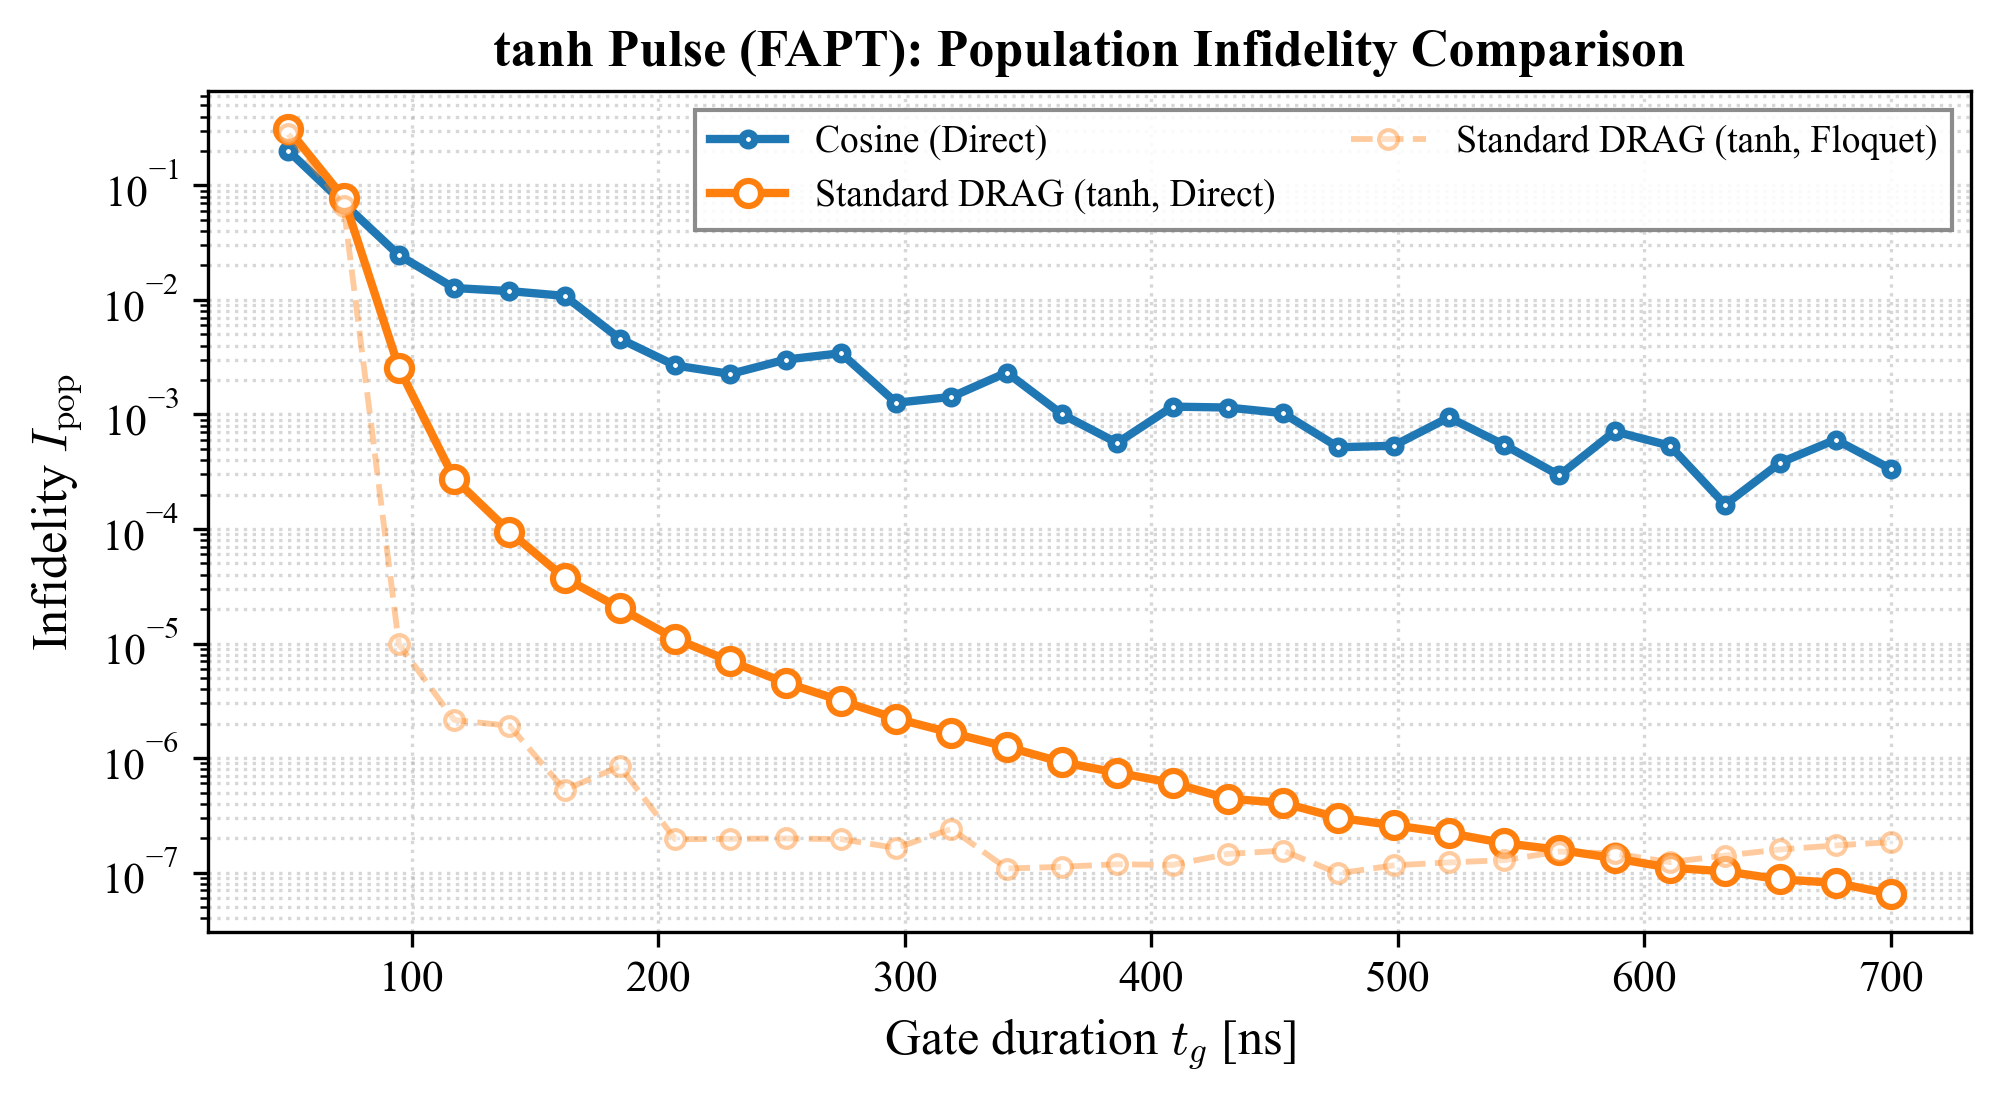

(<Figure size 2040x1140 with 1 Axes>,
 <Axes: title={'center': 'tanh Pulse (FAPT): Population Infidelity Comparison'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Infidelity $I_{\\mathrm{pop}}$'>)

In [ ]:
load_and_plot_standard_custom(use_FAPT=True, pulse="tanh",include_custom=False)

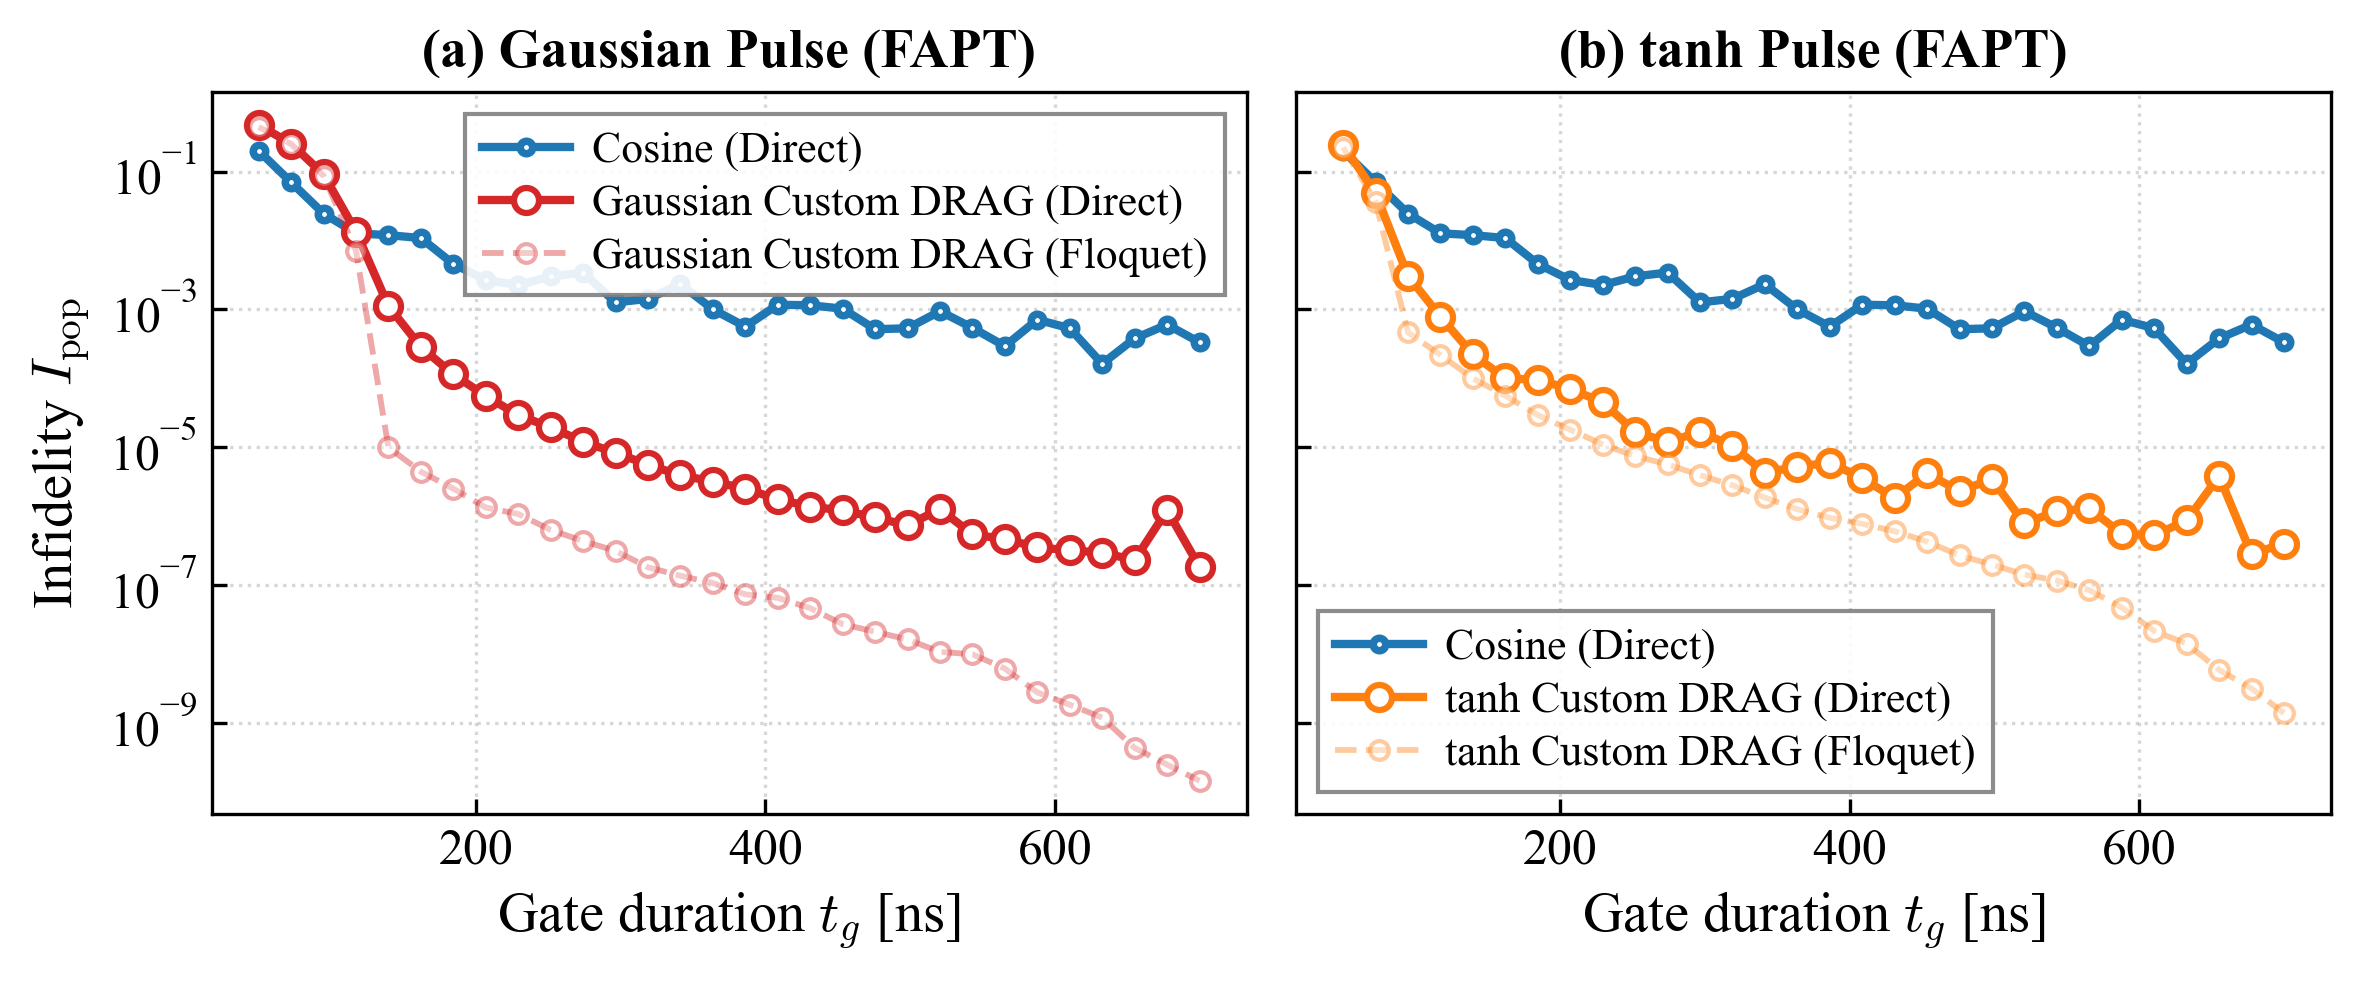

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_combined_gaussian_tanh_custom(
    show=True, use_FAPT=False, savepath=None
):
    setup_paper_style()

    name_addition = "" if not use_FAPT else "_FAPT"
    fapt_str = " (FAPT)" if use_FAPT else ""

    if savepath is None:
        savepath = f"Figure/4/tg_fid_gaussian_tanh_custom{name_addition.lower()}.pdf"

    # Daten laden
    cos_data = np.load("operational_res/cos_popfids_data.npz")
    tg_cos, infid_cos = cos_data["tg_list"], cos_data["infid_pop_list"]

    pulses_info = [
        {"type": "gauss", "label": "Gaussian", "panel": "(a)"},
        {"type": "tanh", "label": "tanh", "panel": "(b)"},
    ]

    # Größere Schriften für hervorragende Lesbarkeit
    plot_style = {
        "axes.labelsize": 13.5,
        "axes.titlesize": 13.0,
        "xtick.labelsize": 12.0,
        "ytick.labelsize": 12.0,
        "legend.fontsize": 10.5,
        "lines.linewidth": 2.0,
        "lines.markersize": 6.0,
    }

    with plt.rc_context(plot_style):
        # figsize auf ein realistisches Paper-Verhältnis angepasst (z. B. 2-column width)
        fig, axes = plt.subplots(
            1, 2, figsize=(8.0, 3.4), sharey=True, dpi=300
        )

        for ax, pinfo in zip(axes, pulses_info):
            pulse = pinfo["type"]
            pulse_label = pinfo["label"]
            panel = pinfo["panel"]

            # Farbdefinitionen
            if pulse == "tanh":
                c_cos = "#1f77b4"
                c_custom = "#ff7f0e"  # Orange für tanh Custom DRAG
            else:
                c_cos = "#1f77b4"
                c_custom = "#d62728"  # Rot für Gaussian Custom DRAG

            # Custom DRAG Daten laden
            custom_data = np.load(
                f"operational_res/drag_popfids/drag_popfids_data_custom{name_addition}_{pulse}.npz"
            )
            tg_custom = custom_data["tg_list"]
            direct_custom = custom_data["direct"]
            floq_custom = custom_data["floq"]

            # Cosine reference
            ax.semilogy(
                tg_cos,
                infid_cos,
                "-",
                color=c_cos,
                marker=".",
                markerfacecolor="white",
                markeredgecolor=c_cos,
                markeredgewidth=1.8,
                label=r"Cosine (Direct)",
            )

            # Custom DRAG (Direct & Floquet)
            ax.semilogy(
                tg_custom,
                direct_custom,
                "-",
                color=c_custom,
                marker="o",
                mfc="white",
                mec=c_custom,
                mew=1.5,
                label=rf"{pulse_label} Custom DRAG (Direct)",
            )
            ax.semilogy(
                tg_custom,
                floq_custom,
                "--",
                color=c_custom,
                marker="o",
                mfc="white",
                mec=c_custom,
                mew=1.0,
                lw=1.4,
                ms=4.5,
                alpha=0.40,
                label=rf"{pulse_label} Custom DRAG (Floquet)",
            )

            ax.set_xlabel(r"Gate duration $t_g$ [ns]")
            ax.set_title(
                rf"{panel} {pulse_label} Pulse{fapt_str}",
                fontweight="bold",
            )
            ax.grid(True, which="both", linestyle=":", alpha=0.5, linewidth=0.8)
            ax.tick_params(direction="in", which="both")
            ax.legend(
                loc="best",
                ncol=1,
                frameon=True,
                fancybox=False,
                edgecolor="gray",
                framealpha=0.9,
                labelspacing=0.3,
                handletextpad=0.5,
            )

        axes[0].set_ylabel(r"Infidelity $I_{\mathrm{pop}}$")
        fig.tight_layout()

        if savepath:
            output_file = Path(savepath)
            output_file.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(output_file, bbox_inches="tight")

        if show:
            plt.show()

    return fig, axes


# Beispielaufruf:
fig, axes = plot_combined_gaussian_tanh_custom(show=True, use_FAPT=True)

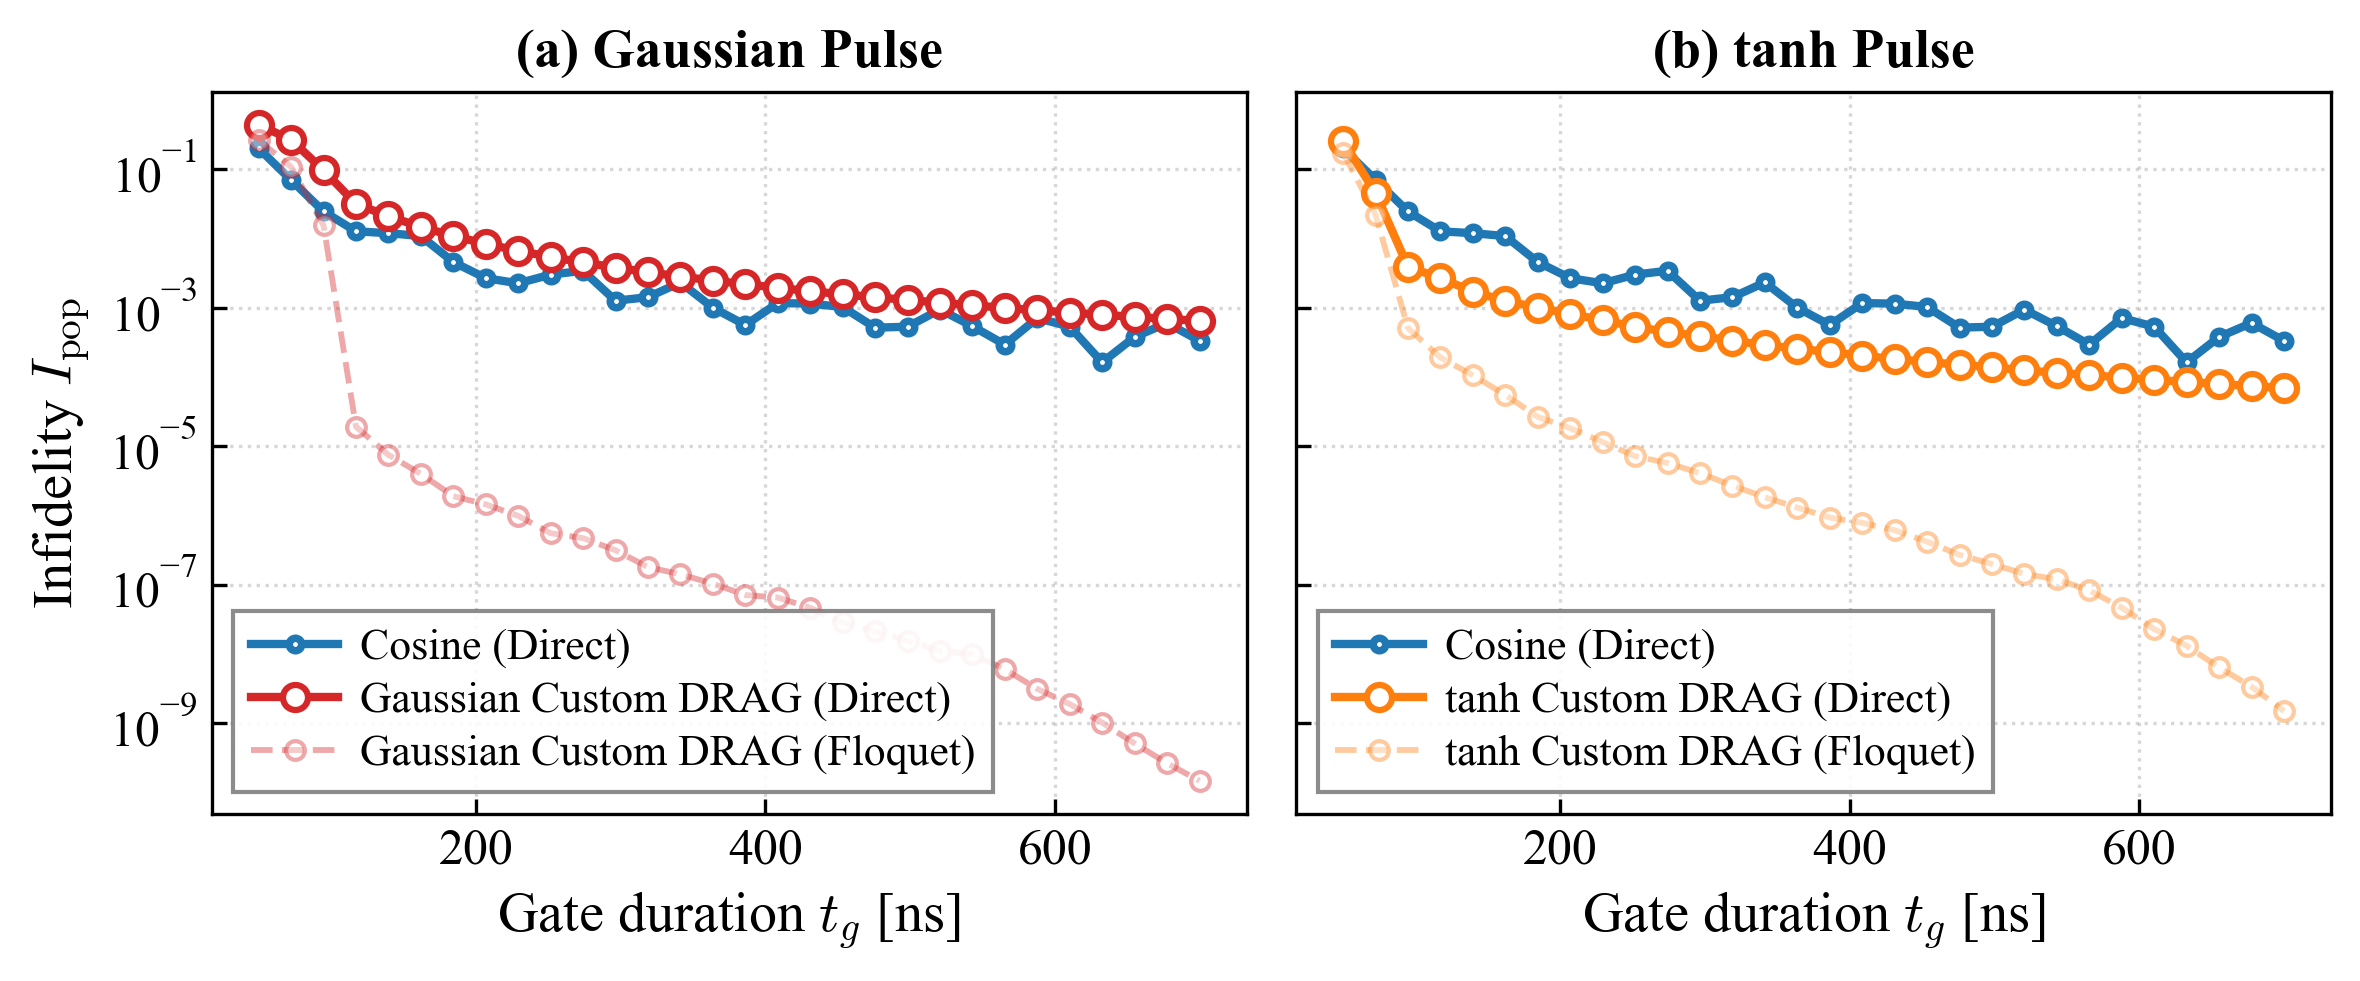

(<Figure size 2400x1020 with 2 Axes>,
 array([<Axes: title={'center': '(a) Gaussian Pulse'}, xlabel='Gate duration $t_g$ [ns]', ylabel='Infidelity $I_{\\mathrm{pop}}$'>,
        <Axes: title={'center': '(b) tanh Pulse'}, xlabel='Gate duration $t_g$ [ns]'>],
       dtype=object))

In [10]:
plot_combined_gaussian_tanh_custom(show=True, use_FAPT=False)